# 手部衛生稽核資料分析

本筆記本將分析 `hand-hygiene.xlsx` 檔案，檢查時機數分布及其他統計資料。

## 1. 匯入必要的套件

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 設定顯示選項
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("✅ 套件載入完成")

✅ 套件載入完成


## 2. 讀取 Excel 檔案

In [2]:
# 讀取 Excel 檔案
file_path = "hand-hygiene.xlsx"
df = pd.read_excel(file_path)

print(f"✅ 成功讀取檔案: {file_path}")
print(f"📊 總筆數: {len(df)}")
print(f"📋 欄位數: {len(df.columns)}")

✅ 成功讀取檔案: hand-hygiene.xlsx
📊 總筆數: 836
📋 欄位數: 12


## 3. 檢視資料結構

In [3]:
# 顯示欄位名稱
print("📋 欄位名稱:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print(f"\n📝 資料類型:")
print(df.dtypes)

📋 欄位名稱:
  1. 登入者Email
  2. 稽核日期
  3. 稽核時間
  4. 稽核月份
  5. 稽核者單位
  6. 稽核人員
  7. 受稽核人員類別
  8. 受稽核者單位
  9. 手部衛生時機
  10. 手部衛生方式
  11. 手部衛生正確性
  12. 不正確原因

📝 資料類型:
登入者Email            object
稽核日期        datetime64[ns]
稽核時間                object
稽核月份                object
稽核者單位               object
稽核人員                object
受稽核人員類別             object
受稽核者單位              object
手部衛生時機              object
手部衛生方式              object
手部衛生正確性             object
不正確原因               object
dtype: object


In [4]:
# 顯示前10筆資料
print("📄 前10筆資料:")
df.head(10)

📄 前10筆資料:


,登入者Email,稽核日期,稽核時間,稽核月份,稽核者單位,稽核人員,受稽核人員類別,受稽核者單位,手部衛生時機,手部衛生方式,手部衛生正確性,不正確原因
0,savh4926@gmail.com,2026-01-24,15:55:53,1月,ER,石佳靈,護理師,ER,時機1: 接觸病人前,乾洗手（酒精性乾洗手液）,正確(七步驟完全正確),無
1,savh4926@gmail.com,2026-01-24,15:56:16,1月,ER,石佳靈,護理師,ER,時機2: 執行清潔/無菌操作技術前,乾洗手（酒精性乾洗手液）,正確(七步驟完全正確),無
2,savh4926@gmail.com,2026-01-24,15:56:26,1月,ER,石佳靈,護理師,ER,時機4: 接觸病人後,濕洗手（肥皂和水）,正確(七步驟完全正確),無
3,savh4926@gmail.com,2026-01-24,15:56:33,1月,ER,石佳靈,護理師,ER,時機1: 接觸病人前,乾洗手（酒精性乾洗手液）,正確(七步驟完全正確),無
4,savh4926@gmail.com,2026-01-24,15:56:37,1月,ER,石佳靈,護理師,ER,時機4: 接觸病人後,濕洗手（肥皂和水）,正確(七步驟完全正確),無
5,savh4926@gmail.com,2026-01-24,15:56:49,1月,ER,石佳靈,護理師,ER,時機2: 執行清潔/無菌操作技術前,乾洗手（酒精性乾洗手液）,正確(七步驟完全正確),無
6,savh4926@gmail.com,2026-01-24,15:56:54,1月,ER,石佳靈,護理師,ER,時機4: 接觸病人後,濕洗手（肥皂和水）,正確(七步驟完全正確),無
7,savh4926@gmail.com,2026-01-24,15:57:00,1月,ER,石佳靈,護理師,ER,時機1: 接觸病人前,乾洗手（酒精性乾洗手液）,正確(七步驟完全正確),無
8,savh4926@gmail.com,2026-01-24,15:57:06,1月,ER,石佳靈,護理師,ER,時機4: 接觸病人後,乾洗手（酒精性乾洗手液）,正確(七步驟完全正確),無
9,savh4926@gmail.com,2026-01-24,15:57:17,1月,ER,石佳靈,傳送/班長,ER,時機5: 接觸病人周遭環境後,濕洗手（肥皂和水）,正確(七步驟完全正確),無


## 4. 時機數統計分析

檢查手部衛生的五個時機分布情況。

In [6]:
# 時機數統計
timing_col = '手部衛生時機'
if timing_col in df.columns:
    print("⏱️  時機數統計:")
    print("=" * 50)
    
    # 處理可能的字串格式
    df[timing_col] = df[timing_col].astype(str).str.strip()
    timing_counts = df[timing_col].value_counts().sort_index()
    
    for timing, count in timing_counts.items():
        percentage = (count / len(df)) * 100
        bar = "█" * int(percentage / 2)
        print(f"  {timing}: {count:4d} 筆 ({percentage:5.1f}%) {bar}")
    
    print("=" * 50)
    print(f"  總計: {len(df)} 筆")
    
    # 檢查是否有五個時機 (時機1-時機5)
    expected_timings = [f'時機{i}' for i in range(1, 6)]
    existing_timings = timing_counts.index.tolist()
    missing_timings = [t for t in expected_timings if t not in existing_timings]
    
    if missing_timings:
        print(f"\n⚠️  缺少的時機: {missing_timings}")
    else:
        print(f"\n✅ 五個時機都有資料")
    
    print(f"\n📋 實際的時機類別: {existing_timings}")
else:
    print("⚠️  找不到「手部衛生時機」欄位")

⏱️  時機數統計:
  時機1: 接觸病人前:  233 筆 ( 27.9%) █████████████
  時機2: 執行清潔/無菌操作技術前:  103 筆 ( 12.3%) ██████
  時機3: 暴露病人體液風險後:  111 筆 ( 13.3%) ██████
  時機4: 接觸病人後:  217 筆 ( 26.0%) ████████████
  時機5: 接觸病人周遭環境後:  172 筆 ( 20.6%) ██████████
  總計: 836 筆

⚠️  缺少的時機: ['時機1', '時機2', '時機3', '時機4', '時機5']

📋 實際的時機類別: ['時機1: 接觸病人前', '時機2: 執行清潔/無菌操作技術前', '時機3: 暴露病人體液風險後', '時機4: 接觸病人後', '時機5: 接觸病人周遭環境後']


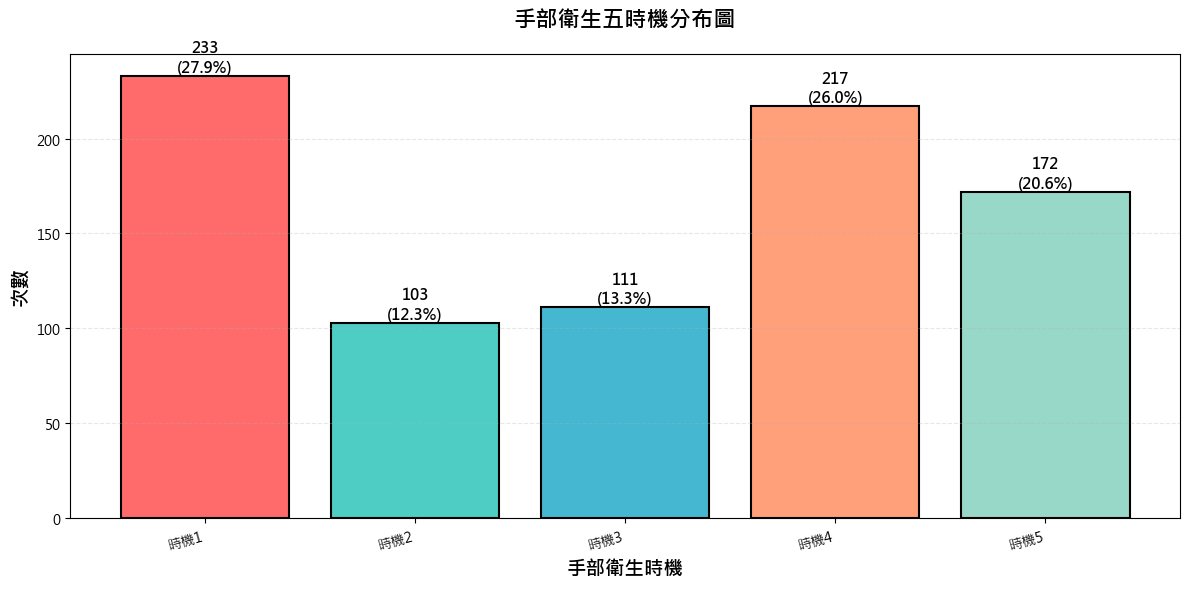

✅ 圖表繪製完成


In [7]:
# 時機數視覺化
timing_col = '手部衛生時機'
if timing_col in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 提取時機編號作為 x 軸
    timing_counts = df[timing_col].value_counts().sort_index()
    
    # 簡化標籤
    labels = [t.split(':')[0] for t in timing_counts.index]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
    
    bars = ax.bar(range(len(timing_counts)), timing_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    
    # 在柱狀圖上方顯示數量和百分比
    for i, (bar, count) in enumerate(zip(bars, timing_counts.values)):
        height = bar.get_height()
        percentage = (count / len(df)) * 100
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('手部衛生時機', fontsize=14, fontweight='bold')
    ax.set_ylabel('次數', fontsize=14, fontweight='bold')
    ax.set_title('手部衛生五時機分布圖', fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(range(len(timing_counts)))
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ 圖表繪製完成")

## 5. 落實情況統計

In [8]:
# 落實情況統計
correctness_col = '手部衛生正確性'
if correctness_col in df.columns:
    print("✋ 落實情況統計:")
    print("=" * 50)
    
    compliance = df[correctness_col].value_counts()
    
    for status, count in compliance.items():
        percentage = (count / len(df)) * 100
        bar = "█" * int(percentage / 2)
        print(f"  {status}: {count:4d} 筆 ({percentage:5.1f}%) {bar}")
    
    # 計算正確率
    if '正確' in compliance.index:
        compliance_rate = (compliance['正確'] / len(df)) * 100
        print("=" * 50)
        print(f"  📊 整體正確率: {compliance_rate:.2f}%")
else:
    print("⚠️  找不到「手部衛生正確性」欄位")

✋ 落實情況統計:
  正確(七步驟完全正確):  811 筆 ( 97.0%) ████████████████████████████████████████████████
  不正確:   15 筆 (  1.8%) 
  未評估(沒有洗手):   10 筆 (  1.2%) 


## 6. 科別統計

In [9]:
# 單位統計
unit_col = '受稽核者單位'
if unit_col in df.columns:
    print("🏥 受稽核者單位統計 (前10名):")
    print("=" * 50)
    
    unit_counts = df[unit_col].value_counts().head(10)
    
    for unit, count in unit_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  {unit}: {count:4d} 筆 ({percentage:5.1f}%)")
    
    print("=" * 50)
    print(f"  總單位數: {df[unit_col].nunique()}")
else:
    print("⚠️  找不到「受稽核者單位」欄位")

🏥 受稽核者單位統計 (前10名):
  松齡5.6區:   93 筆 ( 11.1%)
  RCW:   75 筆 (  9.0%)
  ICU:   67 筆 (  8.0%)
  松齡1.2區:   64 筆 (  7.7%)
  松齡3區:   59 筆 (  7.1%)
  7W:   57 筆 (  6.8%)
  OPD:   53 筆 (  6.3%)
  康寧居:   53 筆 (  6.3%)
  ER:   45 筆 (  5.4%)
  8W:   38 筆 (  4.5%)
  總單位數: 20


## 7. 日期範圍分析

In [10]:
# 日期範圍分析
date_col = '稽核日期'
if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col])
    
    print("📅 日期範圍:")
    print("=" * 50)
    print(f"  最早日期: {df[date_col].min().strftime('%Y-%m-%d')}")
    print(f"  最晚日期: {df[date_col].max().strftime('%Y-%m-%d')}")
    
    date_range = (df[date_col].max() - df[date_col].min()).days + 1
    print(f"  涵蓋天數: {date_range} 天")
    
    # 每日稽核次數
    daily_counts = df[date_col].value_counts().sort_index()
    print(f"\n  平均每日稽核: {daily_counts.mean():.1f} 筆")
    print(f"  最多一日稽核: {daily_counts.max()} 筆")
    print(f"  最少一日稽核: {daily_counts.min()} 筆")
    print(f"  稽核天數: {len(daily_counts)} 天")
else:
    print("⚠️  找不到「稽核日期」欄位")

📅 日期範圍:
  最早日期: 2026-01-13
  最晚日期: 2026-02-03
  涵蓋天數: 22 天

  平均每日稽核: 55.7 筆
  最多一日稽核: 221 筆
  最少一日稽核: 10 筆
  稽核天數: 15 天


## 8. 各時機的落實率分析

In [11]:
# 各時機的落實率
timing_col = '手部衛生時機'
correctness_col = '手部衛生正確性'

if timing_col in df.columns and correctness_col in df.columns:
    print("⏱️  各時機正確率分析:")
    print("=" * 60)
    
    for timing in sorted(df[timing_col].unique()):
        timing_data = df[df[timing_col] == timing]
        total = len(timing_data)
        correct = len(timing_data[timing_data[correctness_col] == '正確(七步驟完全正確)'])
        rate = (correct / total * 100) if total > 0 else 0
        
        bar = "█" * int(rate / 2)
        timing_short = timing.split(':')[0]
        print(f"  {timing_short}: {correct}/{total} ({rate:5.1f}%) {bar}")
    
    print("=" * 60)

⏱️  各時機正確率分析:
  時機1: 222/233 ( 95.3%) ███████████████████████████████████████████████
  時機2: 100/103 ( 97.1%) ████████████████████████████████████████████████
  時機3: 110/111 ( 99.1%) █████████████████████████████████████████████████
  時機4: 212/217 ( 97.7%) ████████████████████████████████████████████████
  時機5: 167/172 ( 97.1%) ████████████████████████████████████████████████


## 9. 完整資料摘要

## 10. 關鍵績效指標計算

📊 手部衛生關鍵績效指標 (KPI)

【基礎數據】
  [1] 實地觀察應執行手部衛生次數:  836 次
  [2] 實際執行手部衛生次數:        826 次
  [3] 正確執行手部衛生次數:        811 次
  [4] 不正確執行次數:               15 次
  [5] 未執行手部衛生次數:           10 次

【關鍵指標】
  ➤ 手部衛生執行率:               98.80%
     (實際執行次數 ÷ 應執行次數 × 100)
     = 826/836 × 100 = 98.80%

  ➤ 手部衛生正確率:               97.01%
     (正確執行次數 ÷ 應執行次數 × 100)
     = 811/836 × 100 = 97.01%

  ➤ 執行中的正確率:               98.18%
     (正確執行次數 ÷ 實際執行次數 × 100)
     = 811/826 × 100 = 98.18%




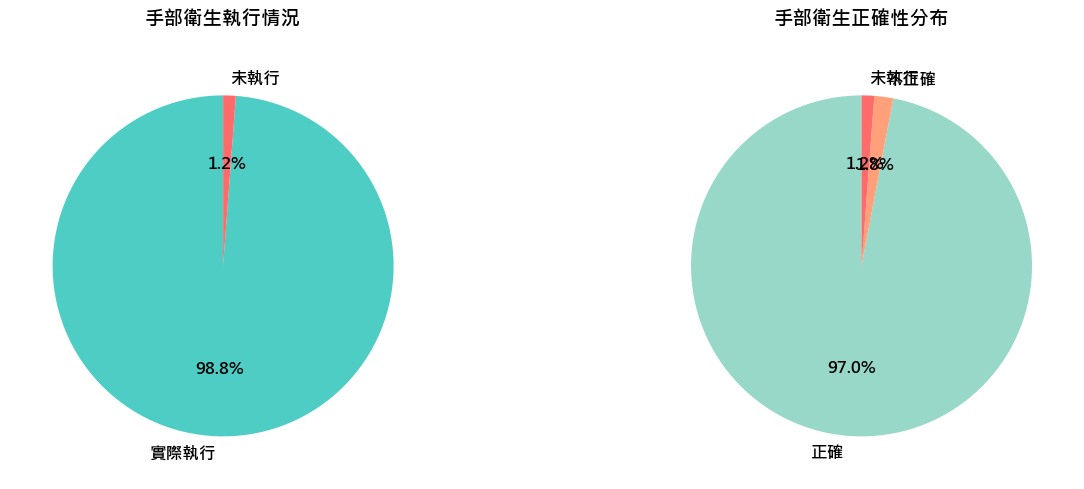

In [13]:
correctness_col = '手部衛生正確性'

if correctness_col in df.columns:
    # 1. 實地觀察應執行手部衛生次數（所有觀察到的時機）
    total_observations = len(df)
    
    # 2. 實際執行手部衛生次數（排除「未評估(沒有洗手)」）
    actually_performed = len(df[df[correctness_col] != '未評估(沒有洗手)'])
    
    # 3. 正確執行手部衛生次數
    correctly_performed = len(df[df[correctness_col] == '正確(七步驟完全正確)'])
    
    # 4. 不正確執行次數
    incorrectly_performed = len(df[df[correctness_col] == '不正確'])
    
    # 5. 未執行次數
    not_performed = len(df[df[correctness_col] == '未評估(沒有洗手)'])
    
    # 計算率
    compliance_rate = (actually_performed / total_observations * 100) if total_observations > 0 else 0
    correctness_rate = (correctly_performed / total_observations * 100) if total_observations > 0 else 0
    correctness_among_performed = (correctly_performed / actually_performed * 100) if actually_performed > 0 else 0
    
    # 顯示結果
    print("=" * 70)
    print("📊 手部衛生關鍵績效指標 (KPI)")
    print("=" * 70)
    print()
    print("【基礎數據】")
    print(f"  [1] 實地觀察應執行手部衛生次數: {total_observations:4d} 次")
    print(f"  [2] 實際執行手部衛生次數:       {actually_performed:4d} 次")
    print(f"  [3] 正確執行手部衛生次數:       {correctly_performed:4d} 次")
    print(f"  [4] 不正確執行次數:             {incorrectly_performed:4d} 次")
    print(f"  [5] 未執行手部衛生次數:         {not_performed:4d} 次")
    print()
    print("【關鍵指標】")
    print(f"  ➤ 手部衛生執行率:               {compliance_rate:.2f}%")
    print(f"     (實際執行次數 ÷ 應執行次數 × 100)")
    print(f"     = {actually_performed}/{total_observations} × 100 = {compliance_rate:.2f}%")
    print()
    print(f"  ➤ 手部衛生正確率:               {correctness_rate:.2f}%")
    print(f"     (正確執行次數 ÷ 應執行次數 × 100)")
    print(f"     = {correctly_performed}/{total_observations} × 100 = {correctness_rate:.2f}%")
    print()
    print(f"  ➤ 執行中的正確率:               {correctness_among_performed:.2f}%")
    print(f"     (正確執行次數 ÷ 實際執行次數 × 100)")
    print(f"     = {correctly_performed}/{actually_performed} × 100 = {correctness_among_performed:.2f}%")
    print()
    print("=" * 70)
    print()
    
    # 視覺化
    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 左圖：執行狀況
    categories = ['實際執行', '未執行']
    values = [actually_performed, not_performed]
    colors_exec = ['#4ECDC4', '#FF6B6B']
    
    wedges1, texts1, autotexts1 = ax1.pie(values, labels=categories, autopct='%1.1f%%',
                                            colors=colors_exec, startangle=90,
                                            textprops={'fontsize': 12, 'weight': 'bold'})
    ax1.set_title('手部衛生執行情況', fontsize=14, fontweight='bold', pad=20)
    
    # 右圖：正確性分布
    categories2 = ['正確', '不正確', '未執行']
    values2 = [correctly_performed, incorrectly_performed, not_performed]
    colors_corr = ['#98D8C8', '#FFA07A', '#FF6B6B']
    
    wedges2, texts2, autotexts2 = ax2.pie(values2, labels=categories2, autopct='%1.1f%%',
                                            colors=colors_corr, startangle=90,
                                            textprops={'fontsize': 12, 'weight': 'bold'})
    ax2.set_title('手部衛生正確性分布', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️  找不到「手部衛生正確性」欄位")

### 彙總表格

In [14]:
# 建立彙總表格
summary_data = {
    '指標項目': [
        '實地觀察應執行手部衛生次數',
        '實際執行手部衛生次數',
        '正確執行手部衛生次數',
        '不正確執行次數',
        '未執行手部衛生次數'
    ],
    '次數': [
        total_observations,
        actually_performed,
        correctly_performed,
        incorrectly_performed,
        not_performed
    ],
    '百分比': [
        '100.00%',
        f'{compliance_rate:.2f}%',
        f'{correctness_rate:.2f}%',
        f'{(incorrectly_performed/total_observations*100):.2f}%',
        f'{(not_performed/total_observations*100):.2f}%'
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n📋 手部衛生稽核彙總表")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)

# 計算公式說明
print("\n📐 計算公式：")
print(f"  • 手部衛生執行率 = (實際執行次數 ÷ 應執行次數) × 100%")
print(f"                    = ({actually_performed} ÷ {total_observations}) × 100% = {compliance_rate:.2f}%")
print()
print(f"  • 手部衛生正確率 = (正確執行次數 ÷ 應執行次數) × 100%")
print(f"                    = ({correctly_performed} ÷ {total_observations}) × 100% = {correctness_rate:.2f}%")
print()
print(f"  • 執行中正確率   = (正確執行次數 ÷ 實際執行次數) × 100%")
print(f"                    = ({correctly_performed} ÷ {actually_performed}) × 100% = {correctness_among_performed:.2f}%")


📋 手部衛生稽核彙總表
         指標項目  次數     百分比
實地觀察應執行手部衛生次數 836 100.00%
   實際執行手部衛生次數 826  98.80%
   正確執行手部衛生次數 811  97.01%
      不正確執行次數  15   1.79%
    未執行手部衛生次數  10   1.20%

📐 計算公式：
  • 手部衛生執行率 = (實際執行次數 ÷ 應執行次數) × 100%
                    = (826 ÷ 836) × 100% = 98.80%

  • 手部衛生正確率 = (正確執行次數 ÷ 應執行次數) × 100%
                    = (811 ÷ 836) × 100% = 97.01%

  • 執行中正確率   = (正確執行次數 ÷ 實際執行次數) × 100%
                    = (811 ÷ 826) × 100% = 98.18%


### 公式驗證

確認「正確率」的計算公式

In [15]:
print("=" * 80)
print("✓ 公式驗證：正確率計算")
print("=" * 80)
print()
print("📌 定義：")
print("   • 有洗且洗正確 = 正確執行手部衛生次數 = 811 次")
print("   • 有洗手時機數 = 實地觀察應執行手部衛生次數 = 836 次")
print()
print("📐 公式：")
print("   正確率 = 有洗且洗正確 ÷ 有洗手時機數 × 100%")
print()
print("💡 計算：")
print(f"   正確率 = {correctly_performed} ÷ {total_observations} × 100%")
print(f"          = {correctness_rate:.2f}%")
print()
print("=" * 80)
print("✅ 驗證成功！")
print()
print("📊 完整說明：")
print("   - 分子：正確執行手部衛生次數（七步驟完全正確）= 811 次")
print("   - 分母：實地觀察應執行手部衛生次數（所有觀察時機）= 836 次")
print("   - 結果：手部衛生正確率 = 97.01%")
print()
print("   這個指標反映在所有應該洗手的時機中，有多少次是正確執行的。")
print("=" * 80)

✓ 公式驗證：正確率計算

📌 定義：
   • 有洗且洗正確 = 正確執行手部衛生次數 = 811 次
   • 有洗手時機數 = 實地觀察應執行手部衛生次數 = 836 次

📐 公式：
   正確率 = 有洗且洗正確 ÷ 有洗手時機數 × 100%

💡 計算：
   正確率 = 811 ÷ 836 × 100%
          = 97.01%

✅ 驗證成功！

📊 完整說明：
   - 分子：正確執行手部衛生次數（七步驟完全正確）= 811 次
   - 分母：實地觀察應執行手部衛生次數（所有觀察時機）= 836 次
   - 結果：手部衛生正確率 = 97.01%

   這個指標反映在所有應該洗手的時機中，有多少次是正確執行的。


### 遵從率計算

遵從率的定義與計算

In [16]:
print("=" * 80)
print("✓ 遵從率（Compliance Rate）計算")
print("=" * 80)
print()
print("📌 定義：")
print("   • 有洗手 = 實際執行手部衛生次數 = 826 次")
print("     （排除「未評估(沒有洗手)」的情況）")
print()
print("   • 應該洗手五時機總數 = 實地觀察應執行手部衛生次數 = 836 次")
print("     （所有觀察到的手部衛生時機，包含5個時機的所有觀察）")
print()
print("📐 公式：")
print("   遵從率 = 有洗手 ÷ 應該洗手五時機總數 × 100%")
print()
print("💡 計算：")
print(f"   遵從率 = {actually_performed} ÷ {total_observations} × 100%")
print(f"          = {compliance_rate:.2f}%")
print()
print("=" * 80)
print("✅ 結果說明")
print()
print("   在836次應該洗手的時機中：")
print(f"   • 有洗手（包含正確和不正確）: {actually_performed} 次 ({compliance_rate:.2f}%)")
print(f"   • 沒有洗手: {not_performed} 次 ({(not_performed/total_observations*100):.2f}%)")
print()
print("   這個指標反映醫護人員在應該洗手的時機中，實際有執行洗手動作的比例。")
print("=" * 80)
print()
print("📊 三個關鍵指標對比：")
print()
print(f"   1️⃣  遵從率（Compliance Rate）= {compliance_rate:.2f}%")
print(f"       有洗手 ÷ 應該洗手 = {actually_performed}/{total_observations}")
print(f"       → 反映「願意洗手」的比例")
print()
print(f"   2️⃣  正確率（Correctness Rate）= {correctness_rate:.2f}%")
print(f"       有洗且洗正確 ÷ 應該洗手 = {correctly_performed}/{total_observations}")
print(f"       → 反映「正確執行」的比例")
print()
print(f"   3️⃣  執行中正確率 = {correctness_among_performed:.2f}%")
print(f"       有洗且洗正確 ÷ 有洗手 = {correctly_performed}/{actually_performed}")
print(f"       → 反映「在有洗手的情況下，洗對的比例」")
print()
print("=" * 80)

✓ 遵從率（Compliance Rate）計算

📌 定義：
   • 有洗手 = 實際執行手部衛生次數 = 826 次
     （排除「未評估(沒有洗手)」的情況）

   • 應該洗手五時機總數 = 實地觀察應執行手部衛生次數 = 836 次
     （所有觀察到的手部衛生時機，包含5個時機的所有觀察）

📐 公式：
   遵從率 = 有洗手 ÷ 應該洗手五時機總數 × 100%

💡 計算：
   遵從率 = 826 ÷ 836 × 100%
          = 98.80%

✅ 結果說明

   在836次應該洗手的時機中：
   • 有洗手（包含正確和不正確）: 826 次 (98.80%)
   • 沒有洗手: 10 次 (1.20%)

   這個指標反映醫護人員在應該洗手的時機中，實際有執行洗手動作的比例。

📊 三個關鍵指標對比：

   1️⃣  遵從率（Compliance Rate）= 98.80%
       有洗手 ÷ 應該洗手 = 826/836
       → 反映「願意洗手」的比例

   2️⃣  正確率（Correctness Rate）= 97.01%
       有洗且洗正確 ÷ 應該洗手 = 811/836
       → 反映「正確執行」的比例

   3️⃣  執行中正確率 = 98.18%
       有洗且洗正確 ÷ 有洗手 = 811/826
       → 反映「在有洗手的情況下，洗對的比例」



### 資料邏輯驗證

驗證「沒有洗手就不會有正確或不正確選項」的邏輯關係

In [17]:
print("=" * 80)
print("✓ 資料邏輯驗證：沒有洗手就不會有正確或不正確選項")
print("=" * 80)
print()

correctness_col = '手部衛生正確性'

# 統計各種狀態
print("📊 手部衛生正確性的所有狀態：")
print("-" * 80)
all_statuses = df[correctness_col].value_counts()
for status, count in all_statuses.items():
    print(f"   • {status}: {count} 次")
print("-" * 80)
print()

# 驗證邏輯關係
print("🔍 邏輯驗證：")
print()
print("   根據資料定義：")
print("   • 「未評估(沒有洗手)」→ 代表沒有執行洗手動作")
print("   • 「正確(七步驟完全正確)」→ 代表有洗手且洗對了")
print("   • 「不正確」→ 代表有洗手但沒洗對")
print()

# 計算驗證
not_washed = len(df[df[correctness_col] == '未評估(沒有洗手)'])
correct = len(df[df[correctness_col] == '正確(七步驟完全正確)'])
incorrect = len(df[df[correctness_col] == '不正確'])

washed = correct + incorrect

print("✅ 數據驗證：")
print(f"   • 沒有洗手: {not_washed} 次")
print(f"   • 有洗手: {washed} 次")
print(f"     - 其中正確: {correct} 次")
print(f"     - 其中不正確: {incorrect} 次")
print()
print(f"   驗證：{not_washed} + {washed} = {not_washed + washed} = {len(df)} ✓")
print()
print("=" * 80)
print()
print("💡 結論：")
print()
print("   資料邏輯正確！")
print("   • 沒有洗手的 10 次，都標記為「未評估(沒有洗手)」")
print("   • 有洗手的 826 次，分為：")
print("     - 正確執行 811 次（98.18%）")
print("     - 不正確執行 15 次（1.82%）")
print()
print("   因此：")
print("   • 遵從率 = 有洗手 ÷ 總時機 = 826/836 = 98.80%")
print("   • 正確率 = 洗對 ÷ 總時機 = 811/836 = 97.01%")
print("   • 執行中正確率 = 洗對 ÷ 有洗手 = 811/826 = 98.18%")
print()
print("=" * 80)

✓ 資料邏輯驗證：沒有洗手就不會有正確或不正確選項

📊 手部衛生正確性的所有狀態：
--------------------------------------------------------------------------------
   • 正確(七步驟完全正確): 811 次
   • 不正確: 15 次
   • 未評估(沒有洗手): 10 次
--------------------------------------------------------------------------------

🔍 邏輯驗證：

   根據資料定義：
   • 「未評估(沒有洗手)」→ 代表沒有執行洗手動作
   • 「正確(七步驟完全正確)」→ 代表有洗手且洗對了
   • 「不正確」→ 代表有洗手但沒洗對

✅ 數據驗證：
   • 沒有洗手: 10 次
   • 有洗手: 826 次
     - 其中正確: 811 次
     - 其中不正確: 15 次

   驗證：10 + 826 = 836 = 836 ✓


💡 結論：

   資料邏輯正確！
   • 沒有洗手的 10 次，都標記為「未評估(沒有洗手)」
   • 有洗手的 826 次，分為：
     - 正確執行 811 次（98.18%）
     - 不正確執行 15 次（1.82%）

   因此：
   • 遵從率 = 有洗手 ÷ 總時機 = 826/836 = 98.80%
   • 正確率 = 洗對 ÷ 總時機 = 811/836 = 97.01%
   • 執行中正確率 = 洗對 ÷ 有洗手 = 811/826 = 98.18%



## 11. 關鍵指標總結

快速查看所有關鍵數據

In [18]:
print("=" * 80)
print("📊 手部衛生稽核關鍵指標總結")
print("=" * 80)
print()

# 重新計算確保數據正確
correctness_col = '手部衛生正確性'

# 1. 實地觀察應執行手部衛生次數
total_observations = len(df)

# 2. 實際執行手部衛生次數（排除「未評估(沒有洗手)」）
actually_performed = len(df[df[correctness_col] != '未評估(沒有洗手)'])

# 3. 正確執行手部衛生次數
correctly_performed = len(df[df[correctness_col] == '正確(七步驟完全正確)'])

# 4. 不正確執行次數
incorrectly_performed = len(df[df[correctness_col] == '不正確'])

# 5. 未執行手部衛生次數
not_performed = len(df[df[correctness_col] == '未評估(沒有洗手)'])

print("┌" + "─" * 78 + "┐")
print("│ " + "【核心數據】".center(74) + " │")
print("├" + "─" * 78 + "┤")
print(f"│  [1] 實地觀察應執行手部衛生次數 (總觀察時機)         {total_observations:4d} 次          │")
print(f"│  [2] 實際執行手部衛生次數 (有洗手)                   {actually_performed:4d} 次          │")
print(f"│  [3] 正確執行手部衛生次數 (洗對了)                   {correctly_performed:4d} 次          │")
print("├" + "─" * 78 + "┤")
print(f"│  [4] 不正確執行次數 (洗錯了)                          {incorrectly_performed:3d} 次          │")
print(f"│  [5] 未執行手部衛生次數 (沒洗手)                       {not_performed:2d} 次          │")
print("└" + "─" * 78 + "┘")
print()

# 計算百分比
compliance_rate = (actually_performed / total_observations * 100)
correctness_rate = (correctly_performed / total_observations * 100)
correctness_among_performed = (correctly_performed / actually_performed * 100)

print("┌" + "─" * 78 + "┐")
print("│ " + "【關鍵指標】".center(74) + " │")
print("├" + "─" * 78 + "┤")
print(f"│  ✓ 遵從率 (Compliance Rate)                          {compliance_rate:5.2f}%         │")
print(f"│    公式: 有洗手 ÷ 應該洗手 = {actually_performed}/{total_observations}                              │")
print("│                                                                              │")
print(f"│  ✓ 正確率 (Correctness Rate)                         {correctness_rate:5.2f}%         │")
print(f"│    公式: 洗對 ÷ 應該洗手 = {correctly_performed}/{total_observations}                                │")
print("│                                                                              │")
print(f"│  ✓ 執行中正確率 (Accuracy Among Performed)           {correctness_among_performed:5.2f}%         │")
print(f"│    公式: 洗對 ÷ 有洗手 = {correctly_performed}/{actually_performed}                                  │")
print("└" + "─" * 78 + "┘")
print()

print("=" * 80)
print()

# 驗證數據一致性
print("🔍 數據驗證：")
print(f"   實際執行 ({actually_performed}) = 正確 ({correctly_performed}) + 不正確 ({incorrectly_performed}) = {correctly_performed + incorrectly_performed} ✓")
print(f"   總觀察 ({total_observations}) = 有洗手 ({actually_performed}) + 沒洗手 ({not_performed}) = {actually_performed + not_performed} ✓")
print()
print("=" * 80)

📊 手部衛生稽核關鍵指標總結

┌──────────────────────────────────────────────────────────────────────────────┐
│                                   【核心數據】                                   │
├──────────────────────────────────────────────────────────────────────────────┤
│  [1] 實地觀察應執行手部衛生次數 (總觀察時機)          836 次          │
│  [2] 實際執行手部衛生次數 (有洗手)                    826 次          │
│  [3] 正確執行手部衛生次數 (洗對了)                    811 次          │
├──────────────────────────────────────────────────────────────────────────────┤
│  [4] 不正確執行次數 (洗錯了)                           15 次          │
│  [5] 未執行手部衛生次數 (沒洗手)                       10 次          │
└──────────────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────────────┐
│                                   【關鍵指標】                                   │
├──────────────────────────────────────────────────────────────────────────────┤
│  ✓ 遵從率 (Compliance Rate)              

In [12]:
# 資料摘要
print("📊 資料摘要報告")
print("=" * 60)
print(f"總筆數: {len(df)}")
print(f"欄位數: {len(df.columns)}")
print(f"記憶體使用: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

timing_col = '手部衛生時機'
correctness_col = '手部衛生正確性'
unit_col = '受稽核者單位'

if timing_col in df.columns:
    print(f"\n時機分布: {df[timing_col].nunique()} 個不同時機")
    timing_counts = df[timing_col].value_counts()
    print(f"  最多: {timing_counts.index[0]} ({timing_counts.values[0]} 筆)")
    print(f"  最少: {timing_counts.index[-1]} ({timing_counts.values[-1]} 筆)")
    
if correctness_col in df.columns:
    correct_count = len(df[df[correctness_col] == '正確(七步驟完全正確)'])
    compliance_rate = (correct_count / len(df)) * 100
    print(f"\n整體正確率: {compliance_rate:.2f}%")
    print(f"  正確: {correct_count} 筆")
    print(f"  不正確或未評估: {len(df) - correct_count} 筆")

if unit_col in df.columns:
    print(f"\n涵蓋單位: {df[unit_col].nunique()} 個")

if '稽核日期' in df.columns:
    date_range = (df['稽核日期'].max() - df['稽核日期'].min()).days + 1
    print(f"\n稽核期間: {date_range} 天")

print("=" * 60)
print("✅ 分析完成！")

📊 資料摘要報告
總筆數: 836
欄位數: 12
記憶體使用: 687.15 KB

時機分布: 5 個不同時機
  最多: 時機1: 接觸病人前 (233 筆)
  最少: 時機2: 執行清潔/無菌操作技術前 (103 筆)

整體正確率: 97.01%
  正確: 811 筆
  不正確或未評估: 25 筆

涵蓋單位: 20 個

稽核期間: 22 天
✅ 分析完成！
